In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [3]:
# Read in SDSS data
from sdss_data.sdss_loader import load_sdss_csv
df = load_sdss_csv("sdss_data/fields/sdss_target.csv")

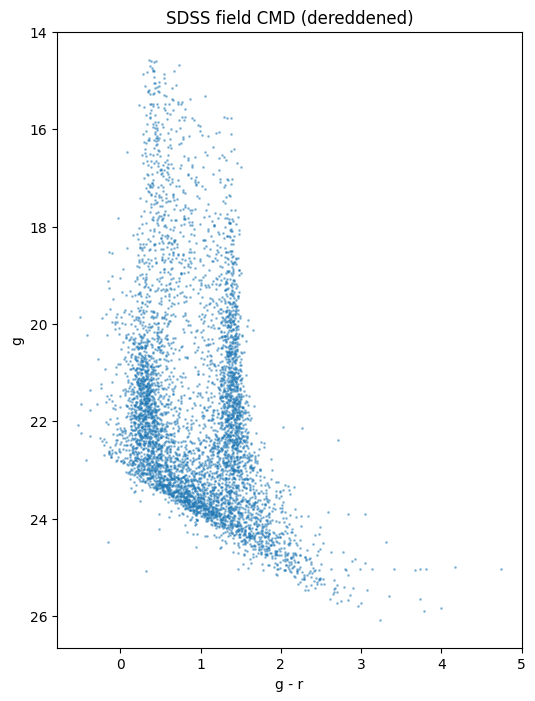

In [4]:
# Plot SDSS data on CMD without reddening as a sanity check
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("g - r")
plt.ylabel("g")
plt.title("SDSS field CMD (dereddened)")
plt.show()

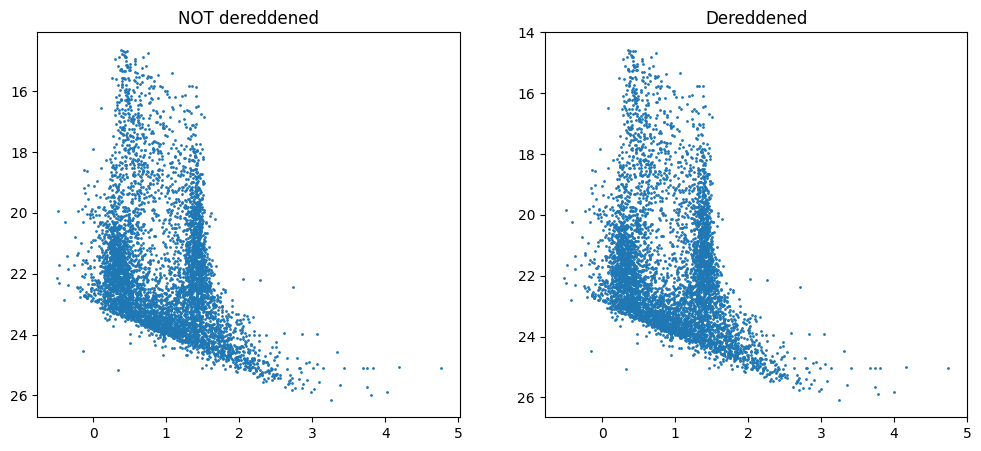

In [5]:
# Plot dereddened vs reddened CMD side by side
plt.figure(figsize=(12,5))

# reddened
plt.subplot(1,2,1)
plt.scatter(df["psfMag_g"]-df["psfMag_r"], df["psfMag_g"], s=1)
plt.gca().invert_yaxis()
plt.title("NOT dereddened")

# dereddened
plt.subplot(1,2,2)
plt.scatter(df["g_r"], df["g0"], s=1)
plt.gca().invert_yaxis()
plt.title("Dereddened")

plt.show()

In [6]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [7]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

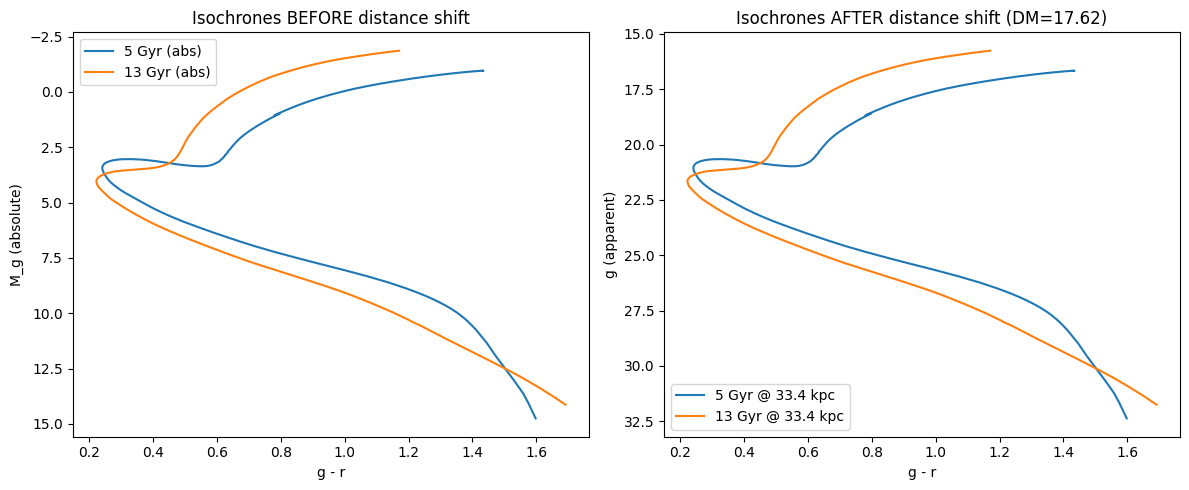

Distance modulus used: DM = 17.6187 mag for d = 33.4 kpc


In [8]:

# --- Distance modulus for d = 33.4 kpc ---
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)   # ~17.62

def iso_before_after(iso, DM):
    """Return (color_abs, Mg_abs, color_app, g_app) for one isochrone."""
    df_iso = iso.df.copy()

    # BEFORE: absolute magnitudes (intrinsic)
    color_abs = df_iso["sdss_g"] - df_iso["sdss_r"]
    Mg_abs = df_iso["sdss_g"]

    # AFTER: shifted to apparent magnitudes at the Sgr distance
    g_app = df_iso["sdss_g"] + DM
    r_app = df_iso["sdss_r"] + DM
    color_app = g_app - r_app

    return color_abs, Mg_abs, color_app, g_app


c5_abs, g5_abs, c5_app, g5_app = iso_before_after(iso5, DM)
c13_abs, g13_abs, c13_app, g13_app = iso_before_after(iso13, DM)

# --- Plot BEFORE/AFTER for distance correction ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# BEFORE (absolute mags)
ax[0].plot(c5_abs, g5_abs, lw=1.5, label="5 Gyr (abs)")
ax[0].plot(c13_abs, g13_abs, lw=1.5, label="13 Gyr (abs)")
ax[0].invert_yaxis()
ax[0].set_xlabel("g - r")
ax[0].set_ylabel("M_g (absolute)")
ax[0].set_title("Isochrones BEFORE distance shift")
ax[0].legend()

# AFTER (apparent mags at 33.4 kpc)
ax[1].plot(c5_app, g5_app, lw=1.5, label="5 Gyr @ 33.4 kpc")
ax[1].plot(c13_app, g13_app, lw=1.5, label="13 Gyr @ 33.4 kpc")
ax[1].invert_yaxis()
ax[1].set_xlabel("g - r")
ax[1].set_ylabel("g (apparent)")
ax[1].set_title(f"Isochrones AFTER distance shift (DM={DM:.2f})")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distance modulus used: DM = {DM:.4f} mag for d = {d_pc/1000:.1f} kpc")

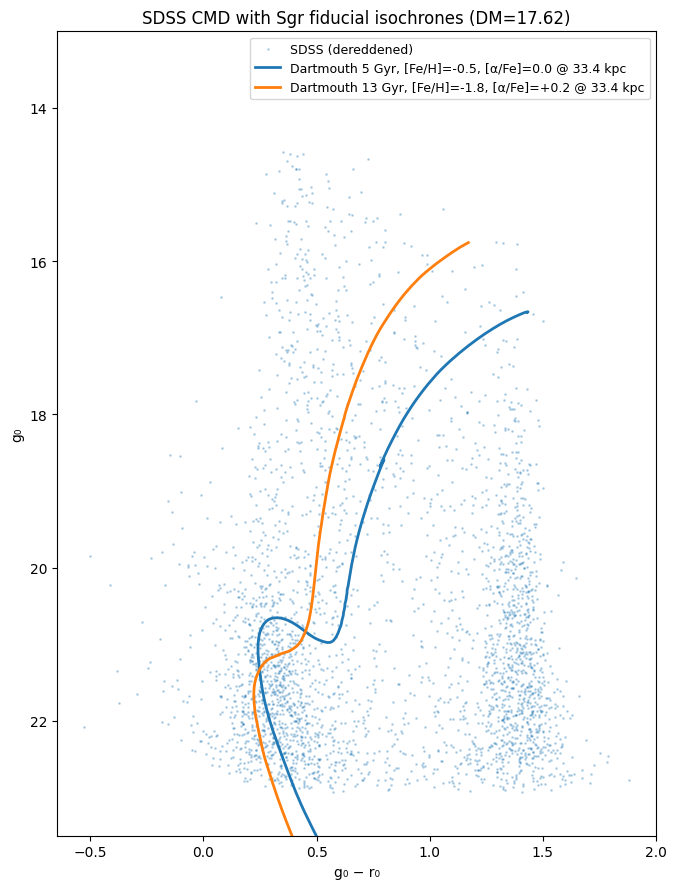

Overlay used DM = 17.6187 mag; SDSS plotted points = 3206 / 5448 (after quality cut)


In [9]:
# --- Overlay dereddened SDSS CMD with distance-shifted Dartmouth isochrones ---
# Distance modulus for Sgr field (33.4 kpc)
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)

# light quality cut to keep the CMD readable
mask = (
    (df["psfMagErr_g"] < 0.15) &
    (df["psfMagErr_r"] < 0.15) &
    (df["g0"] < 23.5) &
    (df["r0"] < 23.5)
)
d = df[mask].copy()

def shifted_iso(iso, DM):
    """Return (color, mag) arrays for plotting an isochrone shifted to apparent mags."""
    iso_df = iso.df
    g_app = iso_df["sdss_g"] + DM
    r_app = iso_df["sdss_r"] + DM
    color = g_app - r_app
    return color.to_numpy(), g_app.to_numpy()

c5, g5 = shifted_iso(iso5, DM)
c13, g13 = shifted_iso(iso13, DM)

plt.figure(figsize=(7, 9))

# SDSS (dereddened)
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.25, label="SDSS (dereddened)")

# Isochrones (shifted to 33.4 kpc; no extinction added)
plt.plot(c5, g5, lw=2, label="Dartmouth 5 Gyr, [Fe/H]=-0.5, [α/Fe]=0.0 @ 33.4 kpc")
plt.plot(c13, g13, lw=2, label="Dartmouth 13 Gyr, [Fe/H]=-1.8, [α/Fe]=+0.2 @ 33.4 kpc")

plt.gca().invert_yaxis()
plt.xlabel("g₀ − r₀")
plt.ylabel("g₀")
plt.title(f"SDSS CMD with Sgr fiducial isochrones (DM={DM:.2f})")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.ylim(23.5, 13)

plt.show()

print(f"Overlay used DM = {DM:.4f} mag; SDSS plotted points = {len(d)} / {len(df)} (after quality cut)")

Total stars after quality cut: 3206
Candidates (5 Gyr only):  183
Candidates (13 Gyr only): 130
Candidates (both):         827
Candidates (either):       1140
(chi2 threshold=6.18, dg_window=±0.5 mag)


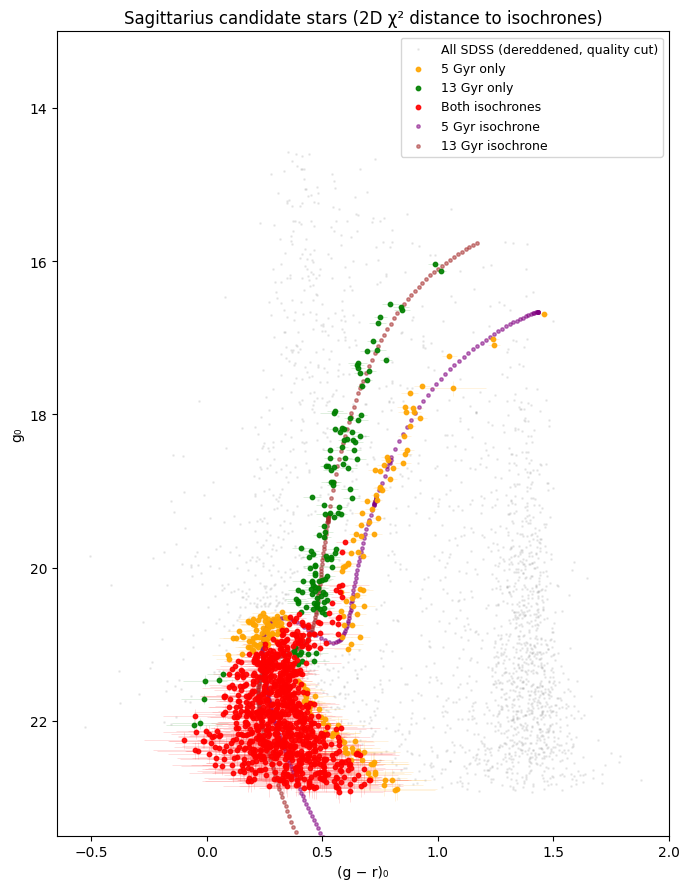

In [10]:
# Color uncertainty (quadrature)
d["sig_gr"] = np.sqrt(d["psfMagErr_g"]**2 + d["psfMagErr_r"]**2)

# Build isochrone point clouds in (g0, (g-r)0) space
def iso_points(iso, DM):
    iso_df = iso.df
    g_app = iso_df["sdss_g"].to_numpy() + DM
    r_app = iso_df["sdss_r"].to_numpy() + DM
    c_app = g_app - r_app
    return g_app, c_app

g5_iso, c5_iso   = iso_points(iso5, DM)
g13_iso, c13_iso = iso_points(iso13, DM)

# -----------------------------
# FIXED candidate metric: 2D chi^2 distance to isochrone
# -----------------------------
CHI2_THRESH = 6.18      # ~95% region for 2 dof (tunable)
DG_WINDOW   = 0.50      # only compare to iso points within +/- this many mag in g

# Star arrays
star_g    = d["g0"].to_numpy()
star_c    = d["g_r"].to_numpy()
sigma_g   = d["psfMagErr_g"].to_numpy()
sigma_c   = d["sig_gr"].to_numpy()

# Prevent divide-by-zero (shouldn't happen, but safe)
sigma_g = np.maximum(sigma_g, 1e-6)
sigma_c = np.maximum(sigma_c, 1e-6)

def min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, iso_g, iso_c, dg_window=0.5, nbins=200):
    """
    Compute minimum chi^2 distance from each star to an isochrone in (g, color) space:
        chi^2 = ((g - g_iso)/sigma_g)^2 + ((c - c_iso)/sigma_c)^2
    Only compare stars to isochrone points within +/- dg_window in g to avoid silly matches.
    Returns: min_chi2 array (len = number of stars).
    """
    # Bin the isochrone points by g to speed up lookup
    gmin, gmax = np.nanmin(iso_g), np.nanmax(iso_g)
    edges = np.linspace(gmin, gmax, nbins + 1)
    bin_id = np.clip(np.digitize(iso_g, edges) - 1, 0, nbins - 1)

    # Store indices for each bin
    bins = [[] for _ in range(nbins)]
    for i, b in enumerate(bin_id):
        bins[b].append(i)

    # For each star, compare only to bins around its g
    min_chi2 = np.full_like(star_g, np.inf, dtype=float)

    # precompute star bin ids
    star_bin = np.clip(np.digitize(star_g, edges) - 1, 0, nbins - 1)

    # How many bins correspond to dg_window?
    dg_per_bin = (gmax - gmin) / nbins
    half_bins = max(1, int(np.ceil(dg_window / dg_per_bin)))

    for j in range(len(star_g)):
        b0 = max(0, star_bin[j] - half_bins)
        b1 = min(nbins - 1, star_bin[j] + half_bins)

        # Gather candidate iso indices
        cand_idx = []
        for b in range(b0, b1 + 1):
            cand_idx.extend(bins[b])

        if not cand_idx:
            continue

        gi = iso_g[cand_idx]
        ci = iso_c[cand_idx]

        # Also enforce absolute dg window (hard cut)
        dg = star_g[j] - gi
        keep = np.abs(dg) <= dg_window
        if not np.any(keep):
            continue

        gi = gi[keep]
        ci = ci[keep]
        dg = dg[keep]
        dc = star_c[j] - ci

        chi2 = (dg / sigma_g[j])**2 + (dc / sigma_c[j])**2
        min_chi2[j] = np.min(chi2)

    return min_chi2

# Compute min chi^2 for each star to each isochrone
chi2_5  = min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, g5_iso,  c5_iso,  dg_window=DG_WINDOW)
chi2_13 = min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, g13_iso, c13_iso, dg_window=DG_WINDOW)

# Candidate flags
is5   = np.isfinite(chi2_5)  & (chi2_5  < CHI2_THRESH)
is13  = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH)
isboth = is5 & is13
is5only = is5 & ~is13
is13only = is13 & ~is5

print(f"Total stars after quality cut: {len(d)}")
print(f"Candidates (5 Gyr only):  {is5only.sum()}")
print(f"Candidates (13 Gyr only): {is13only.sum()}")
print(f"Candidates (both):         {isboth.sum()}")
print(f"Candidates (either):       {(is5 | is13).sum()}")
print(f"(chi2 threshold={CHI2_THRESH}, dg_window=±{DG_WINDOW} mag)")

# -----------------------------
# Plot with faint error bars
# -----------------------------
plt.figure(figsize=(7, 9))

# Background
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.12, color="gray",
            label="All SDSS (dereddened, quality cut)")

def plot_with_errors(mask, color, label):
    x = star_c[mask]
    y = star_g[mask]
    xerr = sigma_c[mask]
    yerr = sigma_g[mask]

    plt.scatter(x, y, s=10, color=color, alpha=0.9, label=label, zorder=3)
    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor=color,
        alpha=0.15,
        elinewidth=0.6,
        capsize=0,
        zorder=2
    )

plot_with_errors(is5only,  "orange", "5 Gyr only")
plot_with_errors(is13only, "green",  "13 Gyr only")
plot_with_errors(isboth,   "red",    "Both isochrones")

# Isochrones as points (no zig-zag lines)
plt.scatter(c5_iso,  g5_iso,  s=6, alpha=0.5, color="purple", label="5 Gyr isochrone")
plt.scatter(c13_iso, g13_iso, s=6, alpha=0.5, color="brown",  label="13 Gyr isochrone")

plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("Sagittarius candidate stars (2D χ² distance to isochrones)")
plt.ylim(23.5, 13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()